/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv
Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB

Missing values:
id             0
date           0
store_n

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02



Date range:
2013-01-01 to 2017-08-15

Target distribution:
count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64


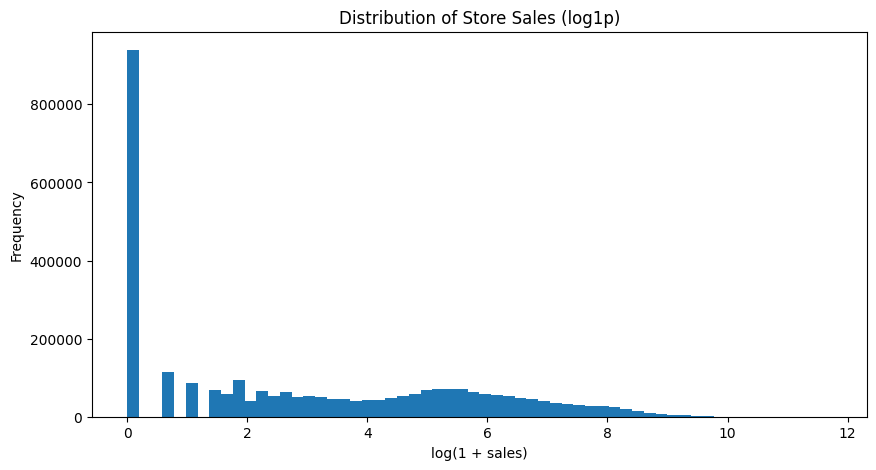

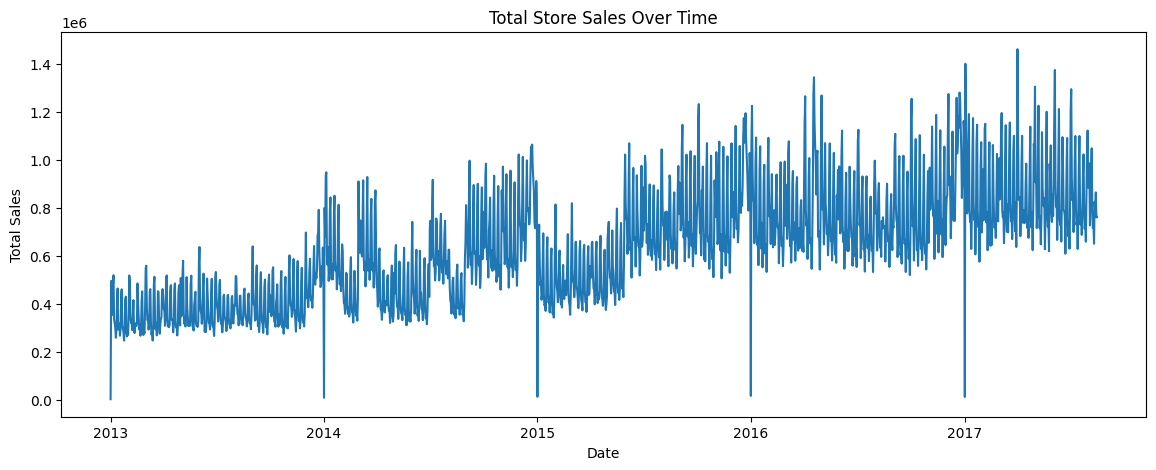

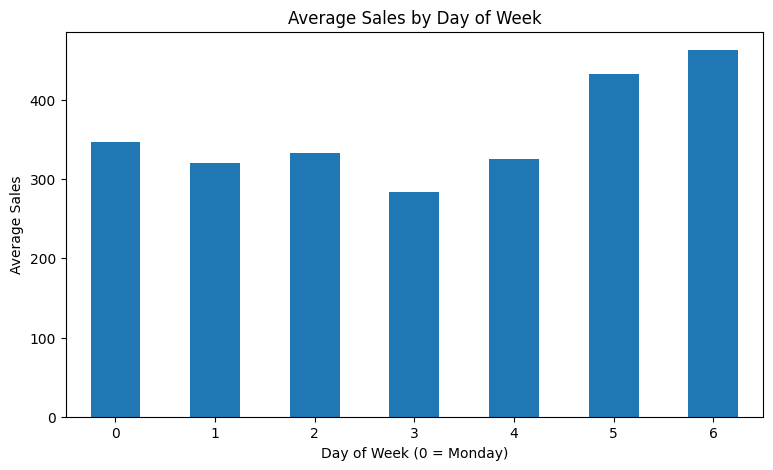

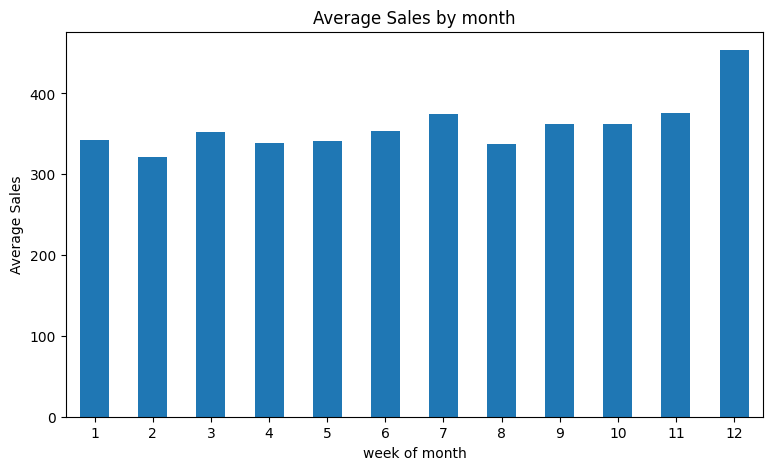

day_ofweek
0    346.544732
1    319.823843
2    332.909401
3    283.540517
4    325.238138
5    433.336472
6    463.085366
Name: sales, dtype: float64
10 lowest-sales dates:
date
2013-01-01      2511.618999
2014-01-01      8602.065404
2017-01-01     12082.500997
2015-01-01     12773.616980
2016-01-01     16433.394000
2013-01-24    247245.690995
2013-03-14    247541.420096
2013-01-10    258982.003049
2013-01-29    264488.818076
2013-06-27    266525.458966
Name: sales, dtype: float64

10 highest-sales dates:
date
2017-04-01    1.463084e+06
2017-01-02    1.402306e+06
2017-06-04    1.376512e+06
2016-04-18    1.345921e+06
2017-05-01    1.306699e+06
2017-07-02    1.296379e+06
2016-12-23    1.282146e+06
2016-12-04    1.276195e+06
2016-04-17    1.271834e+06
2016-05-01    1.270121e+06
Name: sales, dtype: float64
      date    type   locale        description  transferred
2013-01-01 Holiday National Primer dia del ano        False
2014-01-01 Holiday National Primer dia del ano        False
2015-

In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

path = "/kaggle/input/competitions/store-sales-time-series-forecasting/"

train = pd.read_csv(path+"train.csv")
test = pd.read_csv(path+"test.csv")
stores = pd.read_csv(path+"stores.csv")
oil = pd.read_csv(path +"oil.csv")
holidays = pd.read_csv(path + "holidays_events.csv")
transactions = pd.read_csv(path + "transactions.csv")


print("Column information:")
train.info()

print("\nMissing values:")
print(train.isnull().sum())

print("\nStatistical summary:")
display(train.describe())

print("\nDate range:")
print(train["date"].min(), "to", train["date"].max())

print("\nTarget distribution:")
print(train["sales"].describe())
import kagglehub

plt.figure(figsize=(10,5)) 

plt.hist(np.log1p(train["sales"]), bins=60)

plt.title("Distribution of Store Sales (log1p)")
plt.xlabel("log(1 + sales)")
plt.ylabel("Frequency")

plt.show()

train['date'] = pd.to_datetime(train['date'])

daily_sales = train.groupby("date")["sales"].sum()
plt.figure(figsize=(14, 5))
plt.plot(daily_sales.index, daily_sales.values)

plt.title("Total Store Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()
train["day_ofweek"] = train["date"].dt.dayofweek
train["days_ofmonth"] = train["date"].dt.month

week_day_sale = train.groupby("day_ofweek")["sales"].mean()

plt.figure(figsize=(9, 5))
week_day_sale.plot(kind="bar")

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.show()


month_sale = train.groupby("days_ofmonth")["sales"].mean()
plt.figure(figsize = (9,5))
month_sale.plot(kind="bar")
plt.title("Average Sales by month")
plt.xlabel("week of month")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.show()

print(week_day_sale)

daily_sales = train.groupby("date")["sales"].sum()

print("10 lowest-sales dates:")
print(daily_sales.nsmallest(10))

print("\n10 highest-sales dates:")
print(daily_sales.nlargest(10))


# Check holiday records for January 1
jan_first_holidays = holidays[
    pd.to_datetime(holidays["date"]).dt.strftime("%m-%d") == "01-01"
]

print(jan_first_holidays[
    ["date", "type", "locale", "description", "transferred"]
].sort_values("date").to_string(index=False))

# Check total transactions on January 1
transactions["date"] = pd.to_datetime(transactions["date"])

jan_first_transactions = transactions[
    (transactions["date"].dt.month == 1) &
    (transactions["date"].dt.day == 1)
]

print("\nTransactions on January 1:")
print(jan_first_transactions.groupby("date")["transactions"].agg(
    ["sum", "mean", "count"]
))

# Chronological split
validation_start = pd.Timestamp("2017-07-31")

train_baseline = train[train["date"] < validation_start].copy()
valid = train[train["date"] >= validation_start].copy()

print("Training period:",
      train_baseline["date"].min(),
      "to",
      train_baseline["date"].max())

print("Validation period:",
      valid["date"].min(),
      "to",
      valid["date"].max())

print("Training rows:", len(train_baseline))
print("Validation rows:", len(valid))



# Average historical sales for each store and product family
sales_means = (
    train_baseline
    .groupby(["store_nbr", "family"])["sales"]
    .mean()
)

# Predict average sales for each validation row
valid["prediction"] = pd.MultiIndex.from_frame(
    valid[["store_nbr", "family"]]
).map(sales_means)

# RMSLE requires non-negative predictions
valid["prediction"] = valid["prediction"].clip(lower=0)

rmsle = np.sqrt(
    np.mean(
        (
            np.log1p(valid["prediction"].to_numpy()) -
            np.log1p(valid["sales"].to_numpy())
        ) ** 2
    )
)

print("Baseline RMSLE:", rmsle)


# Feature engineering
train_baseline["day_of_week"] = (
    train_baseline["date"].dt.dayofweek
)
valid["day_of_week"] = valid["date"].dt.dayofweek

# Historical average for each store, family, and weekday
weekday_means = (
    train_baseline
    .groupby(["store_nbr", "family", "day_of_week"])["sales"]
    .mean()
    .rename("prediction")
    .reset_index()
)

# Baseline fallback for combinations not found
fallback_means = (
    train_baseline
    .groupby(["store_nbr", "family"])["sales"]
    .mean()
    .rename("fallback")
    .reset_index()
)

# Merge weekday predictions into validation data
valid_weekday = valid.drop(
    columns=["prediction"], errors="ignore"
).merge(
    weekday_means,
    on=["store_nbr", "family", "day_of_week"],
    how="left"
)

valid_weekday = valid_weekday.merge(
    fallback_means,
    on=["store_nbr", "family"],
    how="left"
)

valid_weekday["prediction"] = (
    valid_weekday["prediction"]
    .fillna(valid_weekday["fallback"])
    .clip(lower=0)
)

# Evaluate using RMSLE
weekday_rmsle = np.sqrt(
    np.mean(
        (
            np.log1p(valid_weekday["prediction"].to_numpy()) -
            np.log1p(valid_weekday["sales"].to_numpy())
        ) ** 2
    )
)


# Add month to both datasets
train_baseline["month"] = train_baseline["date"].dt.month
valid["month"] = valid["date"].dt.month

# Historical average by store, family, weekday, and month
monthly_weekday_means = (
    train_baseline
    .groupby(
        ["store_nbr", "family", "day_of_week", "month"]
    )["sales"]
    .mean()
    .rename("prediction")
    .reset_index()
)

# Merge predictions into validation rows
valid_monthly = valid.drop(
    columns=["prediction"], errors="ignore"
).merge(
    monthly_weekday_means,
    on=["store_nbr", "family", "day_of_week", "month"],
    how="left"
)

# Fall back to the weekday model for unseen combinations
valid_monthly = valid_monthly.merge(
    weekday_means.rename(columns={"prediction": "fallback"}),
    on=["store_nbr", "family", "day_of_week"],
    how="left"
)

valid_monthly["prediction"] = (
    valid_monthly["prediction"]
    .fillna(valid_monthly["fallback"])
    .clip(lower=0)
)

monthly_weekday_rmsle = np.sqrt(
    np.mean(
        (
            np.log1p(valid_monthly["prediction"].to_numpy()) -
            np.log1p(valid_monthly["sales"].to_numpy())
        ) ** 2
    )
)

print("Original baseline RMSLE: 0.694527")
print("Weekday baseline RMSLE: ", weekday_rmsle)
print("Month + weekday RMSLE:  ", monthly_weekday_rmsle)




print("Missing monthly predictions before fallback:",
      valid_monthly["prediction"].isna().sum())

print("Validation rows:", len(valid_monthly))

print("\nPrediction summary:")
print(valid_monthly["prediction"].describe())

print("\nActual sales summary:")
print(valid_monthly["sales"].describe())

In [2]:

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_log_error

# Work on independent copies
ml_train = train_baseline.copy()
ml_valid = valid.copy()

# Date features
for df in [ml_train, ml_valid]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["day_of_year"] = df["date"].dt.dayofyear
    df["is_weekend"] = (
        df["day_of_week"] >= 5
    ).astype(int)

# Encode categories consistently across both datasets
families = {
    family: i
    for i, family in enumerate(train["family"].unique())
}

for df in [ml_train, ml_valid]:
    df["family_encoded"] = df["family"].map(families)

features = [
    "store_nbr",
    "family_encoded",
    "onpromotion",
    "year",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "is_weekend",
]

X_train = ml_train[features]
y_train = np.log1p(ml_train["sales"])

X_valid = ml_valid[features]
y_valid = ml_valid["sales"]

print("Training features:", X_train.shape)
print("Validation features:", X_valid.shape)
print("Missing training features:", X_train.isnull().sum().sum())
print("Missing validation features:", X_valid.isnull().sum().sum())




model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.1,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

model.fit(X_train, y_train)

# Convert log predictions back to sales
predictions = np.expm1(model.predict(X_valid))
predictions = np.clip(predictions, 0, None)

ml_rmsle = np.sqrt(
    mean_squared_log_error(y_valid, predictions)
)

print("Original baseline RMSLE: 0.694527")
print("Weekday baseline RMSLE: ", weekday_rmsle)
print("Month + weekday RMSLE:  ", monthly_weekday_rmsle)
print("Gradient boosting RMSLE:", ml_rmsle)



# Compare actual sales with predicted sales
results = pd.DataFrame({
    "date": ml_valid["date"].to_numpy(),
    "store_nbr": ml_valid["store_nbr"].to_numpy(),
    "family": ml_valid["family"].to_numpy(),
    "actual_sales": y_valid.to_numpy(),
    "predicted_sales": predictions
})

results["absolute_error"] = (
    results["actual_sales"] - results["predicted_sales"]
).abs()

print("Overall validation RMSLE:", ml_rmsle)

print("\nActual vs predicted sales:")
print(results[["actual_sales", "predicted_sales"]].describe())

# Error by product family
family_errors = (
    results.groupby("family")
    .apply(
        lambda g: np.sqrt(
            np.mean(
                (
                    np.log1p(g["actual_sales"]) -
                    np.log1p(g["predicted_sales"])
                ) ** 2
            )
        ),
        include_groups=False
    )
    .sort_values(ascending=False)
)

print("\nFamilies with highest RMSLE:")
print(family_errors.head(10))

Training features: (2972376, 9)
Validation features: (28512, 9)
Missing training features: 0
Missing validation features: 0
Original baseline RMSLE: 0.694527
Weekday baseline RMSLE:  0.6916290559438286
Month + weekday RMSLE:   0.9396559877959125
Gradient boosting RMSLE: 0.6491495258605161
Overall validation RMSLE: 0.6491495258605161

Actual vs predicted sales:
       actual_sales  predicted_sales
count  28512.000000     28512.000000
mean     467.142950       389.922540
std     1248.390215       960.941297
min        0.000000         0.000000
25%        4.000000         3.434285
50%       30.000000        23.931890
75%      278.625500       261.687345
max    15190.000000     11068.889864

Families with highest RMSLE:
family
LAWN AND GARDEN               1.081236
LADIESWEAR                    1.022417
LINGERIE                      0.926033
EGGS                          0.842835
SCHOOL AND OFFICE SUPPLIES    0.823044
GROCERY II                    0.804522
MEATS                         0.7

In [3]:

print(stores.head())
print("\nStore columns:")
print(stores.columns.tolist())

print("\nStore types:")
print(stores["type"].value_counts())

print("\nStore clusters:")
print(stores["cluster"].nunique())


store_features = ["store_nbr", "city", "state", "type", "cluster"]

ml_train_store = ml_train.merge(
    stores[store_features],
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

ml_valid_store = ml_valid.merge(
    stores[store_features],
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

print("Training shape:", ml_train_store.shape)
print("Validation shape:", ml_valid_store.shape)

print("Missing store metadata:")
print(ml_train_store[["city", "state", "type", "cluster"]].isna().sum())


# Start from the original feature list
store_model_features = features + ["city", "state", "type", "cluster"]

# Convert categorical features to category codes
for col in ["city", "state", "type"]:
    categories = pd.Index(
        pd.concat([
            ml_train_store[col],
            ml_valid_store[col]
        ]).dropna().unique()
    )

    ml_train_store[col + "_code"] = (
        pd.Categorical(
            ml_train_store[col],
            categories=categories
        ).codes
    )

    ml_valid_store[col + "_code"] = (
        pd.Categorical(
            ml_valid_store[col],
            categories=categories
        ).codes
    )

# Use encoded columns instead of raw strings
store_model_features = features + [
    "city_code",
    "state_code",
    "type_code",
    "cluster"
]

X_train_store = ml_train_store[store_model_features]
X_valid_store = ml_valid_store[store_model_features]

print("Training features:", X_train_store.shape)
print("Validation features:", X_valid_store.shape)
print("Missing training values:", X_train_store.isnull().sum().sum())
print("Missing validation values:", X_valid_store.isnull().sum().sum())


store_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.1,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

store_model.fit(X_train_store, y_train)

store_predictions = np.expm1(
    store_model.predict(X_valid_store)
)
store_predictions = np.clip(store_predictions, 0, None)

store_rmsle = np.sqrt(
    mean_squared_log_error(y_valid, store_predictions)
)

print("Previous best RMSLE:", ml_rmsle)
print("Store metadata RMSLE:", store_rmsle)

   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

Store columns:
['store_nbr', 'city', 'state', 'type', 'cluster']

Store types:
type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64

Store clusters:
17
Training shape: (2972376, 19)
Validation shape: (28512, 20)
Missing store metadata:
city       0
state      0
type       0
cluster    0
dtype: int64
Training features: (2972376, 13)
Validation features: (28512, 13)
Missing training values: 0
Missing validation values: 0
Previous best RMSLE: 0.6491495258605161
Store metadata RMSLE: 0.6347853711852827


In [4]:
oil["date"] = pd.to_datetime(oil["date"])


print(oil.shape)
print(oil.isna().sum())
print(oil.head())

oil["dcoilwtico"] = oil["dcoilwtico"].ffill().bfill()

print("Missing oil prices after filling:", oil["dcoilwtico"].isna().sum())
print(oil.head())

ml_train_oil = ml_train_store.merge(
    oil[["date", "dcoilwtico"]],
    on="date",
    how="left",
    validate="many_to_one"
)

ml_valid_oil = ml_valid_store.merge(
    oil[["date", "dcoilwtico"]],
    on="date",
    how="left",
    validate="many_to_one"
)

print("Training shape:", ml_train_oil.shape)
print("Validation shape:", ml_valid_oil.shape)

print("Missing training oil values:", ml_train_oil["dcoilwtico"].isna().sum())
print("Missing validation oil values:", ml_valid_oil["dcoilwtico"].isna().sum()
     )

oil_features = store_model_features + ["dcoilwtico"]

X_train_oil = ml_train_oil[oil_features]
X_valid_oil = ml_valid_oil[oil_features]

oil_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.1,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

oil_model.fit(X_train_oil, y_train)

oil_predictions = np.clip(
    np.expm1(oil_model.predict(X_valid_oil)),
    0,
    None
)

oil_rmsle = np.sqrt(
    mean_squared_log_error(y_valid, oil_predictions)
)

print("Best score without oil:", store_rmsle)
print("Score with oil:", oil_rmsle)



oil_daily = oil[["date", "dcoilwtico"]].copy()
oil_daily = oil_daily.sort_values("date")

train_sorted = ml_train_store.sort_values("date").copy()
valid_sorted = ml_valid_store.sort_values("date").copy()

ml_train_oil = pd.merge_asof(
    train_sorted,
    oil_daily,
    on="date",
    direction="backward"
)

ml_valid_oil = pd.merge_asof(
    valid_sorted,
    oil_daily,
    on="date",
    direction="backward"
)

print("Missing training oil values:",
      ml_train_oil["dcoilwtico"].isna().sum())

print("Missing validation oil values:",
      ml_valid_oil["dcoilwtico"].isna().sum())


oil_features = store_model_features + ["dcoilwtico"]

X_train_oil = ml_train_oil[oil_features]
X_valid_oil = ml_valid_oil[oil_features]

y_train_oil = np.log1p(ml_train_oil["sales"])
y_valid_oil = ml_valid_oil["sales"]

oil_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.1,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

oil_model.fit(X_train_oil, y_train_oil)

oil_predictions = np.clip(
    np.expm1(oil_model.predict(X_valid_oil)),
    0,
    None
)

oil_rmsle = np.sqrt(
    mean_squared_log_error(y_valid_oil, oil_predictions)
)

print("Store metadata baseline:", store_rmsle)
print("Oil-enhanced RMSLE:", oil_rmsle)

(1218, 2)
date           0
dcoilwtico    43
dtype: int64
        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20
Missing oil prices after filling: 0
        date  dcoilwtico
0 2013-01-01       93.14
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20
Training shape: (2972376, 23)
Validation shape: (28512, 24)
Missing training oil values: 850014
Missing validation oil values: 7128
Best score without oil: 0.6347853711852827
Score with oil: 0.6338048250869563
Missing training oil values: 0
Missing validation oil values: 0
Store metadata baseline: 0.6347853711852827
Oil-enhanced RMSLE: 0.6120936536678421


In [5]:
print(holidays.columns.tolist())
print(holidays.shape)
print(holidays.head(10))
print(holidays.isna().sum())

holidays["date"] = pd.to_datetime(holidays["date"])

print(holidays["locale"].value_counts())
print("\nHoliday types:")
print(holidays["type"].value_counts())

print("\nTransferred holidays:")
print(holidays["transferred"].value_counts())

holidays["date"] = pd.to_datetime(holidays["date"])

national = holidays[
    (holidays["locale"] == "National") &
    (~holidays["transferred"])
].copy()

national_holiday_dates = set(
    national.loc[national["type"] == "Holiday", "date"]
)

national_event_dates = set(national["date"])

for df in [ml_train_oil, ml_valid_oil]:
    df["is_national_holiday"] = (
        df["date"].isin(national_holiday_dates).astype(int)
    )

    df["is_national_event"] = (
        df["date"].isin(national_event_dates).astype(int)
    )

print("Training holiday days:",
      ml_train_oil["is_national_holiday"].sum())
print("Training national event days:",
      ml_train_oil["is_national_event"].sum())

print("Validation holiday days:",
      ml_valid_oil["is_national_holiday"].sum())
print("Validation national event days:",
      ml_valid_oil["is_national_event"].sum())


holiday_features = oil_features + [
    "is_national_holiday",
    "is_national_event"
]

X_train_holiday = ml_train_oil[holiday_features]
X_valid_holiday = ml_valid_oil[holiday_features]

y_train_holiday = np.log1p(ml_train_oil["sales"])
y_valid_holiday = ml_valid_oil["sales"]

holiday_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.1,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

holiday_model.fit(X_train_holiday, y_train_holiday)

holiday_predictions = np.clip(
    np.expm1(holiday_model.predict(X_valid_holiday)),
    0,
    None
)

holiday_rmsle = np.sqrt(
    mean_squared_log_error(y_valid_holiday, holiday_predictions)
)

print("Oil-only RMSLE:", oil_rmsle)
print("Oil + holiday features RMSLE:", holiday_rmsle)

['date', 'type', 'locale', 'locale_name', 'description', 'transferred']
(350, 6)
         date     type    locale locale_name                    description  \
0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3  2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4  2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   
5  2012-05-12  Holiday     Local        Puyo         Cantonizacion del Puyo   
6  2012-06-23  Holiday     Local    Guaranda      Cantonizacion de Guaranda   
7  2012-06-25  Holiday  Regional    Imbabura  Provincializacion de Imbabura   
8  2012-06-25  Holiday     Local   Latacunga     Cantonizacion de Latacunga   
9  2012-06-25  Holiday     Local     Machala           Fundacion de Machala   

   transferred  
0        False  
1        False 

In [6]:
print("Validation period:")
print(ml_valid_oil["date"].min(), "to", ml_valid_oil["date"].max())

print("\nNational holidays in validation:")
print(
    holidays[
        (holidays["locale"] == "National") &
        (holidays["type"] == "Holiday") &
        (~holidays["transferred"]) &
        (holidays["date"].isin(ml_valid_oil["date"].unique()))
    ][["date", "description", "transferred"]]
)

print("\nValidation event feature counts:")
print(ml_valid_oil["is_national_event"].value_counts())


# Start with original training data
lag_data = train.copy()
lag_data["date"] = pd.to_datetime(lag_data["date"])

lag_data = lag_data.sort_values(
    ["store_nbr", "family", "date"]
).reset_index(drop=True)

group_cols = ["store_nbr", "family"]

# Past sales features
lag_data["lag_7"] = (
    lag_data.groupby(group_cols)["sales"].shift(7)
)

lag_data["lag_14"] = (
    lag_data.groupby(group_cols)["sales"].shift(14)
)

lag_data["rolling_mean_7"] = (
    lag_data.groupby(group_cols)["sales"]
    .transform(lambda s: s.shift(1).rolling(7).mean())
)

print(lag_data[[
    "date", "store_nbr", "family", "sales",
    "lag_7", "lag_14", "rolling_mean_7"
]].head(15))


# Chronological split
lag_train = lag_data[lag_data["date"] < "2017-07-31"].copy()
lag_valid = lag_data[
    (lag_data["date"] >= "2017-07-31") &
    (lag_data["date"] <= "2017-08-15")
].copy()

print("Training rows:", len(lag_train))
print("Validation rows:", len(lag_valid))

print("Missing lag features in training:")
print(lag_train[["lag_7", "lag_14", "rolling_mean_7"]].isna().sum())

print("Missing lag features in validation:")
print(lag_valid[["lag_7", "lag_14", "rolling_mean_7"]].isna().sum())

Validation period:
2017-07-31 00:00:00 to 2017-08-15 00:00:00

National holidays in validation:
Empty DataFrame
Columns: [date, description, transferred]
Index: []

Validation event feature counts:
is_national_event
0    26730
1     1782
Name: count, dtype: int64
         date  store_nbr      family  sales  lag_7  lag_14  rolling_mean_7
0  2013-01-01          1  AUTOMOTIVE    0.0    NaN     NaN             NaN
1  2013-01-02          1  AUTOMOTIVE    2.0    NaN     NaN             NaN
2  2013-01-03          1  AUTOMOTIVE    3.0    NaN     NaN             NaN
3  2013-01-04          1  AUTOMOTIVE    3.0    NaN     NaN             NaN
4  2013-01-05          1  AUTOMOTIVE    5.0    NaN     NaN             NaN
5  2013-01-06          1  AUTOMOTIVE    2.0    NaN     NaN             NaN
6  2013-01-07          1  AUTOMOTIVE    0.0    NaN     NaN             NaN
7  2013-01-08          1  AUTOMOTIVE    2.0    0.0     NaN        2.142857
8  2013-01-09          1  AUTOMOTIVE    2.0    2.0     NaN   

In [7]:
# Select store metadata
store_cols = ["store_nbr", "city", "state", "type", "cluster"]

# Merge store metadata
lag_train = lag_train.merge(
    stores[store_cols],
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

lag_valid = lag_valid.merge(
    stores[store_cols],
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

# Merge oil prices using the latest available prior observation
oil_daily = oil[["date", "dcoilwtico"]].sort_values("date")

lag_train = pd.merge_asof(
    lag_train.sort_values("date"),
    oil_daily,
    on="date",
    direction="backward"
)

lag_valid = pd.merge_asof(
    lag_valid.sort_values("date"),
    oil_daily,
    on="date",
    direction="backward"
)

print("Training shape:", lag_train.shape)
print("Validation shape:", lag_valid.shape)
print("Missing oil values:", 
      lag_train["dcoilwtico"].isna().sum(),
      lag_valid["dcoilwtico"].isna().sum())

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_log_error

lag_features = [
    "store_nbr", "onpromotion",
    "year", "month", "day", "day_of_week",
    "day_of_year", "is_weekend",
    "lag_7", "lag_14", "rolling_mean_7",
    "city", "state", "type", "cluster",
    "dcoilwtico"
]

# Create date features
for df in [lag_train, lag_valid]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["day_of_year"] = df["date"].dt.dayofyear
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Encode categorical features consistently
for col in ["city", "state", "type", "family"]:
    categories = pd.Index(
        pd.concat([lag_train[col], lag_valid[col]]).dropna().unique()
    )
    for df in [lag_train, lag_valid]:
        df[col + "_code"] = pd.Categorical(
            df[col], categories=categories
        ).codes

# Use family code instead of family text
lag_features = [
    c if c != "family" else "family_code"
    for c in lag_features
]
lag_features.remove("city")
lag_features.remove("state")
lag_features.remove("type")
lag_features += ["city_code", "state_code", "type_code"]

# Fill early-series lag gaps
lag_train[["lag_7", "lag_14", "rolling_mean_7"]] = (
    lag_train[["lag_7", "lag_14", "rolling_mean_7"]].fillna(0)
)

X_train_lag = lag_train[lag_features]
X_valid_lag = lag_valid[lag_features]

y_train_lag = np.log1p(lag_train["sales"])
y_valid_lag = lag_valid["sales"]

lag_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.1,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

lag_model.fit(X_train_lag, y_train_lag)

lag_predictions = np.clip(
    np.expm1(lag_model.predict(X_valid_lag)),
    0,
    None
)

lag_rmsle = np.sqrt(
    mean_squared_log_error(y_valid_lag, lag_predictions)
)

print("Previous best RMSLE:", oil_rmsle)
print("Lag-feature RMSLE:", lag_rmsle)

lag_results = pd.DataFrame({
    "date": lag_valid["date"].to_numpy(),
    "store_nbr": lag_valid["store_nbr"].to_numpy(),
    "family": lag_valid["family"].to_numpy(),
    "actual_sales": y_valid_lag.to_numpy(),
    "predicted_sales": lag_predictions
})

lag_results["absolute_error"] = (
    lag_results["actual_sales"] -
    lag_results["predicted_sales"]
).abs()

print(lag_results.head(10))

print("\nPrediction summary:")
print(lag_results[["actual_sales", "predicted_sales"]].describe())

Training shape: (2972376, 16)
Validation shape: (28512, 16)
Missing oil values: 0 0
Previous best RMSLE: 0.6120936536678421
Lag-feature RMSLE: 0.4043278940182869
        date  store_nbr            family  actual_sales  predicted_sales  \
0 2017-07-31          1        AUTOMOTIVE         8.000         3.786229   
1 2017-07-31         26         MAGAZINES         0.000         0.061963   
2 2017-07-31         26  LIQUOR,WINE,BEER         2.000        17.470171   
3 2017-07-31          4        LADIESWEAR        15.000        14.736454   
4 2017-07-31         26          LINGERIE         0.000         1.156854   
5 2017-07-31         53        GROCERY II        18.000        16.124586   
6 2017-07-31         26   LAWN AND GARDEN         4.000         6.094325   
7 2017-07-31         26             MEATS       247.516       342.652005   
8 2017-07-31         26        LADIESWEAR         0.000         0.262949   
9 2017-07-31         26   HOME APPLIANCES         0.000         0.474926   

 

In [8]:
family_scores = lag_results.groupby("family").apply(
    lambda g: np.sqrt(
        mean_squared_log_error(
            g["actual_sales"],
            g["predicted_sales"]
        )
    ),
    include_groups=False
).sort_values(ascending=False)

print("10 hardest product families:")
print(family_scores.head(10))

print("\n10 easiest product families:")
print(family_scores.tail(10))

hard_families = [
    "LINGERIE",
    "SCHOOL AND OFFICE SUPPLIES",
    "GROCERY II",
    "CELEBRATION",
    "MAGAZINES"
]

hard_family_summary = (
    lag_results[lag_results["family"].isin(hard_families)]
    .groupby("family")
    .agg(
        actual_mean=("actual_sales", "mean"),
        predicted_mean=("predicted_sales", "mean"),
        actual_median=("actual_sales", "median"),
        zero_sales_pct=(
            "actual_sales",
            lambda s: (s == 0).mean() * 100
        ),
        rows=("actual_sales", "size")
    )
    .sort_values("actual_mean", ascending=False)
)

print(hard_family_summary.round(2))

second_valid_start = pd.Timestamp("2017-07-01")
second_valid_end = pd.Timestamp("2017-07-16")

second_train = lag_data[
    lag_data["date"] < second_valid_start
].copy()

second_valid = lag_data[
    (lag_data["date"] >= second_valid_start) &
    (lag_data["date"] <= second_valid_end)
].copy()

print("Training period:",
      second_train["date"].min(), "to", second_train["date"].max())
print("Validation period:",
      second_valid["date"].min(), "to", second_valid["date"].max())
print("Training rows:", len(second_train))
print("Validation rows:", len(second_valid))

10 hardest product families:
family
LINGERIE                      0.636803
SCHOOL AND OFFICE SUPPLIES    0.586061
GROCERY II                    0.583923
CELEBRATION                   0.563159
MAGAZINES                     0.549214
HARDWARE                      0.546291
LIQUOR,WINE,BEER              0.537265
AUTOMOTIVE                    0.527790
SEAFOOD                       0.504542
PLAYERS AND ELECTRONICS       0.490816
dtype: float64

10 easiest product families:
family
PERSONAL CARE    0.236044
HOME CARE        0.229126
POULTRY          0.225428
BEVERAGES        0.209603
DELI             0.192569
BREAD/BAKERY     0.179939
PRODUCE          0.171283
GROCERY I        0.166817
DAIRY            0.162409
BOOKS            0.089321
dtype: float64
                            actual_mean  predicted_mean  actual_median  \
family                                                                   
SCHOOL AND OFFICE SUPPLIES        59.95           45.86            1.0   
GROCERY II               

In [9]:
# Prepare oil data ONCE
oil["date"] = pd.to_datetime(oil["date"])

oil_daily = (
    oil[["date", "dcoilwtico"]]
    .sort_values("date")
    .copy()
)

# Fill missing oil prices
oil_daily["dcoilwtico"] = (
    oil_daily["dcoilwtico"].ffill().bfill()
)

oil_daily = oil_daily.reset_index(drop=True)

print(
    "Missing oil prices in source:",
    oil_daily["dcoilwtico"].isna().sum()
)

# Ensure consistent date types
second_train["date"] = pd.to_datetime(second_train["date"])
second_valid["date"] = pd.to_datetime(second_valid["date"])

# Remove any existing oil column if this cell was partially rerun
second_train = second_train.drop(
    columns=["dcoilwtico"], errors="ignore"
)
second_valid = second_valid.drop(
    columns=["dcoilwtico"], errors="ignore"
)

# Sort by date for merge_asof
second_train = second_train.sort_values("date").reset_index(drop=True)
second_valid = second_valid.sort_values("date").reset_index(drop=True)

# Merge the prepared oil data
second_train = pd.merge_asof(
    second_train,
    oil_daily,
    on="date",
    direction="backward"
)

second_valid = pd.merge_asof(
    second_valid,
    oil_daily,
    on="date",
    direction="backward"
)

# Verify
print("Training shape:", second_train.shape)
print("Validation shape:", second_valid.shape)

print(
    "Missing oil:",
    second_train["dcoilwtico"].isna().sum(),
    second_valid["dcoilwtico"].isna().sum()
)

Missing oil prices in source: 0
Training shape: (2918916, 12)
Validation shape: (28512, 12)
Missing oil: 0 0


In [10]:
store_cols = ["store_nbr", "city", "state", "type", "cluster"]

second_train = second_train.merge(
    stores[store_cols],
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

second_valid = second_valid.merge(
    stores[store_cols],
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

# Encode categories consistently across training and validation
for col in ["family", "city", "state", "type"]:
    categories = pd.Index(
        pd.concat([second_train[col], second_valid[col]])
        .dropna()
        .unique()
    )

    for df in [second_train, second_valid]:
        df[col + "_code"] = pd.Categorical(
            df[col],
            categories=categories
        ).codes

print("Category encoding complete.")

Category encoding complete.


In [11]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_log_error
import numpy as np

features_lag = [
    "store_nbr", "family_code", "onpromotion",
    "year", "month", "day", "day_of_week",
    "day_of_year", "is_weekend",
    "lag_7", "lag_14", "rolling_mean_7",
    "city_code", "state_code", "type_code",
    "cluster", "dcoilwtico"
]


# Recreate calendar features immediately before training

for df in [second_train, second_valid]:
    df["date"] = pd.to_datetime(df["date"])

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["day_of_year"] = df["date"].dt.dayofyear
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Verify all expected model features exist
missing_train = set(features_lag) - set(second_train.columns)
missing_valid = set(features_lag) - set(second_valid.columns)

print("Missing training features:", missing_train)
print("Missing validation features:", missing_valid)

assert not missing_train, "Training features are still missing"
assert not missing_valid, "Validation features are still missing"

print("All model features are ready.")

# Prepare data
X_train = second_train[features_lag].copy()
y_train = second_train["sales"]

X_valid = second_valid[features_lag].copy()
y_valid = second_valid["sales"]

# Train on log-transformed sales
model_second = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.1,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

model_second.fit(X_train, np.log1p(y_train))

# Predict and calculate RMSLE
pred_second = np.expm1(model_second.predict(X_valid))
pred_second = np.clip(pred_second, 0, None)

rmsle_second = np.sqrt(
    mean_squared_log_error(y_valid, pred_second)
)

print(f"Second validation RMSLE: {rmsle_second:.6f}")

Missing training features: set()
Missing validation features: set()
All model features are ready.
Second validation RMSLE: 0.382465


In [12]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Stores:", stores.shape)
print("Oil:", oil.shape)
print("Model:", type(model_second).__name__)

Train: (3000888, 8)
Test: (28512, 5)
Stores: (54, 5)
Oil: (1218, 2)
Model: HistGradientBoostingRegressor


In [13]:

import pandas as pd
import numpy as np

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_log_error

# --------------------------------------------------
# 1. Define the simulation period
# --------------------------------------------------
forecast_start = pd.Timestamp("2017-07-16")
forecast_end = pd.Timestamp("2017-07-31")
training_end = forecast_start - pd.Timedelta(days=1)

# --------------------------------------------------
# 2. Prepare historical data and lag features
# --------------------------------------------------
history_data = train.copy()
history_data["date"] = pd.to_datetime(history_data["date"])

history_data = history_data.sort_values(
    ["store_nbr", "family", "date"]
).reset_index(drop=True)

grouped_sales = history_data.groupby(
    ["store_nbr", "family"]
)["sales"]

history_data["lag_7"] = grouped_sales.shift(7)
history_data["lag_14"] = grouped_sales.shift(14)

history_data["rolling_mean_7"] = (
    history_data.groupby(["store_nbr", "family"])["sales"]
    .transform(lambda s: s.shift(1).rolling(7).mean())
)

lag_cols = ["lag_7", "lag_14", "rolling_mean_7"]

# Train only on dates before the forecast starts
simulation_train = history_data[
    history_data["date"] <= training_end
].copy()

simulation_train[lag_cols] = (
    simulation_train[lag_cols].fillna(0)
)

# --------------------------------------------------
# 3. Add calendar and store features
# --------------------------------------------------
store_cols = ["store_nbr", "city", "state", "type", "cluster"]

simulation_train = simulation_train.merge(
    stores[store_cols],
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

def add_calendar_features(df):
    df = df.copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["day_of_year"] = df["date"].dt.dayofyear
    df["is_weekend"] = (
        df["day_of_week"] >= 5
    ).astype(int)
    return df

simulation_train = add_calendar_features(simulation_train)

# --------------------------------------------------
# 4. Prepare oil prices
# --------------------------------------------------
oil_daily = oil[["date", "dcoilwtico"]].copy()
oil_daily["date"] = pd.to_datetime(oil_daily["date"])

oil_daily = (
    oil_daily.sort_values("date")
    .reset_index(drop=True)
)

oil_daily["dcoilwtico"] = (
    oil_daily["dcoilwtico"].ffill().bfill()
)

simulation_train = simulation_train.sort_values(
    "date"
).reset_index(drop=True)

simulation_train = pd.merge_asof(
    simulation_train,
    oil_daily,
    on="date",
    direction="backward"
)

# --------------------------------------------------
# 5. Encode categories consistently
# --------------------------------------------------
category_cols = ["family", "city", "state", "type"]

category_maps = {}

for col in category_cols:
    categories = pd.Index(
        pd.concat([
            simulation_train[col],
            stores[col] if col in stores.columns
            else simulation_train[col]
        ]).dropna().unique()
    )

    category_maps[col] = categories

    simulation_train[col + "_code"] = pd.Categorical(
        simulation_train[col],
        categories=categories
    ).codes

features_lag = [
    "store_nbr", "family_code", "onpromotion",
    "year", "month", "day", "day_of_week",
    "day_of_year", "is_weekend",
    "lag_7", "lag_14", "rolling_mean_7",
    "city_code", "state_code", "type_code",
    "cluster", "dcoilwtico"
]

# --------------------------------------------------
# 6. Train a fresh model through July 15
# --------------------------------------------------
X_sim_train = simulation_train[features_lag].copy()
y_sim_train = simulation_train["sales"]

simulation_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.1,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

simulation_model.fit(
    X_sim_train,
    np.log1p(y_sim_train)
)

print("Model trained through:", training_end.date())
print("Training rows:", len(simulation_train))



# Create forecast rows without using their actual sales
future_rows = train.copy()
future_rows["date"] = pd.to_datetime(future_rows["date"])

future_rows = future_rows[
    (future_rows["date"] >= forecast_start) &
    (future_rows["date"] <= forecast_end)
][["id", "date", "store_nbr", "family", "onpromotion"]].copy()

future_rows = future_rows.merge(
    stores[store_cols],
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

future_rows = add_calendar_features(future_rows)

future_rows = pd.merge_asof(
    future_rows.sort_values("date").reset_index(drop=True),
    oil_daily,
    on="date",
    direction="backward"
)

for col in category_cols:
    future_rows[col + "_code"] = pd.Categorical(
        future_rows[col],
        categories=category_maps[col]
    ).codes

# Keep actual historical sales only through July 15.
sales_history = {
    (store, family): list(
        group.sort_values("date")["sales"].astype(float)
    )
    for (store, family), group in
    history_data[
        history_data["date"] <= training_end
    ].groupby(["store_nbr", "family"])
}

recursive_predictions = []

for forecast_date in pd.date_range(
    forecast_start, forecast_end, freq="D"
):
    day_rows = future_rows[
        future_rows["date"] == forecast_date
    ].copy()

    lag7_values = []
    lag14_values = []
    rolling_values = []

    for row in day_rows.itertuples():
        key = (row.store_nbr, row.family)
        past_sales = sales_history[key]

        lag7_values.append(
            past_sales[-7] if len(past_sales) >= 7 else 0
        )
        lag14_values.append(
            past_sales[-14] if len(past_sales) >= 14 else 0
        )
        rolling_values.append(
            np.mean(past_sales[-7:])
            if len(past_sales) >= 7 else 0
        )

    day_rows["lag_7"] = lag7_values
    day_rows["lag_14"] = lag14_values
    day_rows["rolling_mean_7"] = rolling_values

    # Predict this date
    X_day = day_rows[features_lag]
    day_predictions = np.expm1(
        simulation_model.predict(X_day)
    )
    day_predictions = np.clip(day_predictions, 0, None)

    day_rows["predicted_sales"] = day_predictions
    recursive_predictions.append(
        day_rows[["id", "date", "store_nbr",
                  "family", "predicted_sales"]].copy()
    )

    # Append predictions to history for future days.
    # Do NOT append the actual sales.
    for row, prediction in zip(
        day_rows.itertuples(), day_predictions
    ):
        key = (row.store_nbr, row.family)
        sales_history[key].append(float(prediction))

recursive_results = pd.concat(
    recursive_predictions, ignore_index=True
)

print("Forecast rows:", len(recursive_results))
print("Forecast dates:",
      recursive_results["date"].min().date(),
      "to",
      recursive_results["date"].max().date())
print(recursive_results.head())


actual_sales = train.copy()
actual_sales["date"] = pd.to_datetime(actual_sales["date"])

actual_sales = actual_sales[
    (actual_sales["date"] >= forecast_start) &
    (actual_sales["date"] <= forecast_end)
][["id", "sales"]]

recursive_results = recursive_results.merge(
    actual_sales,
    on="id",
    how="left",
    validate="one_to_one"
)

recursive_rmsle = np.sqrt(
    mean_squared_log_error(
        recursive_results["sales"],
        recursive_results["predicted_sales"]
    )
)

print(f"16-day recursive RMSLE: {recursive_rmsle:.6f}")

# Daily scores help reveal error accumulation
daily_scores = (
    recursive_results.groupby("date")
    .apply(
        lambda g: np.sqrt(
            mean_squared_log_error(
                g["sales"], g["predicted_sales"]
            )
        ),
        include_groups=False
    )
    .rename("RMSLE")
    .reset_index()
)

print(daily_scores)

Model trained through: 2017-07-15
Training rows: 2945646
Forecast rows: 28512
Forecast dates: 2017-07-16 to 2017-07-31
        id       date  store_nbr        family  predicted_sales
0  2945646 2017-07-16          1    AUTOMOTIVE         3.204310
1  2946840 2017-07-16         42   CELEBRATION        11.009473
2  2946839 2017-07-16         42  BREAD/BAKERY       720.229379
3  2946838 2017-07-16         42         BOOKS         0.000000
4  2946837 2017-07-16         42     BEVERAGES      3712.353571
16-day recursive RMSLE: 0.427638
         date     RMSLE
0  2017-07-16  0.377454
1  2017-07-17  0.383592
2  2017-07-18  0.382204
3  2017-07-19  0.399729
4  2017-07-20  0.408448
5  2017-07-21  0.413410
6  2017-07-22  0.396404
7  2017-07-23  0.417343
8  2017-07-24  0.444464
9  2017-07-25  0.434014
10 2017-07-26  0.437149
11 2017-07-27  0.457861
12 2017-07-28  0.458765
13 2017-07-29  0.456875
14 2017-07-30  0.476739
15 2017-07-31  0.477840


In [14]:

# Prepare all historical training data for the final model
final_data = train.copy()

final_data["date"] = pd.to_datetime(final_data["date"])

final_data = final_data.sort_values(
    ["store_nbr", "family", "date"]
).reset_index(drop=True)

grouped_sales = final_data.groupby(
    ["store_nbr", "family"]
)["sales"]

final_data["lag_7"] = grouped_sales.shift(7)
final_data["lag_14"] = grouped_sales.shift(14)

final_data["rolling_mean_7"] = (
    final_data.groupby(["store_nbr", "family"])["sales"]
    .transform(lambda s: s.shift(1).rolling(7).mean())
)

lag_cols = ["lag_7", "lag_14", "rolling_mean_7"]
final_data[lag_cols] = final_data[lag_cols].fillna(0)

print("Training rows:", len(final_data))
print("Date range:", final_data["date"].min(),
      "to", final_data["date"].max())
print("Missing lag values:", final_data[lag_cols].isna().sum().sum())


# Add calendar features
final_data["year"] = final_data["date"].dt.year
final_data["month"] = final_data["date"].dt.month
final_data["day"] = final_data["date"].dt.day
final_data["day_of_week"] = final_data["date"].dt.dayofweek
final_data["day_of_year"] = final_data["date"].dt.dayofyear
final_data["is_weekend"] = (
    final_data["day_of_week"] >= 5
).astype(int)

# Add store information
store_cols = ["store_nbr", "city", "state", "type", "cluster"]

final_data = final_data.merge(
    stores[store_cols],
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

# Prepare oil data
oil_daily = oil[["date", "dcoilwtico"]].copy()
oil_daily["date"] = pd.to_datetime(oil_daily["date"])

oil_daily = oil_daily.sort_values("date").reset_index(drop=True)
oil_daily["dcoilwtico"] = (
    oil_daily["dcoilwtico"].ffill().bfill()
)

# Merge latest available oil observation
final_data = final_data.sort_values("date").reset_index(drop=True)

final_data = pd.merge_asof(
    final_data,
    oil_daily,
    on="date",
    direction="backward"
)

# Encode categories
category_cols = ["family", "city", "state", "type"]
category_maps = {}

for col in category_cols:
    categories = pd.Index(final_data[col].dropna().unique())
    category_maps[col] = categories

    final_data[col + "_code"] = pd.Categorical(
        final_data[col],
        categories=categories
    ).codes

# Define model features
features_lag = [
    "store_nbr", "family_code", "onpromotion",
    "year", "month", "day", "day_of_week",
    "day_of_year", "is_weekend",
    "lag_7", "lag_14", "rolling_mean_7",
    "city_code", "state_code", "type_code",
    "cluster", "dcoilwtico"
]

print("Feature count:", len(features_lag))
print("Missing feature values:",
      final_data[features_lag].isna().sum().sum())

# Train final model
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np

final_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.1,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

final_model.fit(
    final_data[features_lag],
    np.log1p(final_data["sales"])
)

print("Final model training complete!")

Training rows: 3000888
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Missing lag values: 0
Feature count: 17
Missing feature values: 0
Final model training complete!


In [15]:

# Prepare test data
test_future = test.copy()
test_future["date"] = pd.to_datetime(test_future["date"])

test_future = test_future.merge(
    stores[store_cols],
    on="store_nbr",
    how="left",
    validate="many_to_one"
)

# Add calendar features
test_future["year"] = test_future["date"].dt.year
test_future["month"] = test_future["date"].dt.month
test_future["day"] = test_future["date"].dt.day
test_future["day_of_week"] = test_future["date"].dt.dayofweek
test_future["day_of_year"] = test_future["date"].dt.dayofyear
test_future["is_weekend"] = (
    test_future["day_of_week"] >= 5
).astype(int)

# Add oil prices
test_future = pd.merge_asof(
    test_future.sort_values("date").reset_index(drop=True),
    oil_daily,
    on="date",
    direction="backward"
)

# Encode categories using the same mapping as training
for col in category_cols:
    test_future[col + "_code"] = pd.Categorical(
        test_future[col],
        categories=category_maps[col]
    ).codes

# Build historical sales lists from all actual training data
sales_history = {
    (store, family): list(
        group.sort_values("date")["sales"].astype(float)
    )
    for (store, family), group in
    train.groupby(["store_nbr", "family"])
}

# Forecast one day at a time
recursive_predictions = []

for forecast_date in sorted(test_future["date"].unique()):
    day_rows = test_future[
        test_future["date"] == forecast_date
    ].copy()

    lag7_values = []
    lag14_values = []
    rolling_values = []

    for row in day_rows.itertuples():
        key = (row.store_nbr, row.family)
        past_sales = sales_history[key]

        lag7_values.append(
            past_sales[-7] if len(past_sales) >= 7 else 0
        )
        lag14_values.append(
            past_sales[-14] if len(past_sales) >= 14 else 0
        )
        rolling_values.append(
            np.mean(past_sales[-7:])
            if len(past_sales) >= 7 else 0
        )

    day_rows["lag_7"] = lag7_values
    day_rows["lag_14"] = lag14_values
    day_rows["rolling_mean_7"] = rolling_values

    predictions = np.expm1(
        final_model.predict(day_rows[features_lag])
    )
    predictions = np.clip(predictions, 0, None)

    day_rows["sales"] = predictions
    recursive_predictions.append(
        day_rows[["id", "sales"]].copy()
    )

    # Update history using predictions, not actual test sales
    for row, prediction in zip(day_rows.itertuples(), predictions):
        key = (row.store_nbr, row.family)
        sales_history[key].append(float(prediction))

submission = pd.concat(
    recursive_predictions,
    ignore_index=True
)

# Restore original test row order
submission = (
    test[["id"]]
    .merge(submission, on="id", how="left", validate="one_to_one")
)

print("Submission shape:", submission.shape)
print("Missing predictions:", submission["sales"].isna().sum())
print("Negative predictions:", (submission["sales"] < 0).sum())
print(submission.head())


# Validate the submission structure
assert len(submission) == len(test)
assert submission["id"].equals(test["id"])
assert submission["sales"].notna().all()
assert (submission["sales"] >= 0).all()

# Save CSV
submission.to_csv("submission.csv", index=False)

print("Saved submission.csv successfully!")
print(submission.shape)

Submission shape: (28512, 2)
Missing predictions: 0
Negative predictions: 0
        id        sales
0  3000888     3.501044
1  3000889     0.037526
2  3000890     4.859111
3  3000891  2041.721843
4  3000892     0.044019
Saved submission.csv successfully!
(28512, 2)
